 Устройство: cpu
 СИСТЕМА КЛАССИФИКАЦИИ АСТРОНОМИЧЕСКИХ ОБЪЕКТОВ
 Дата: 2026-06-04 14:26:13
 Python: 3.13.5
 PyTorch: 2.11.0+cpu
 Устройство: CPU

Данные: C:\Users\ASUS\Desktop\мо\датасет
 Модели: C:\Users\ASUS\models
 Результаты: C:\Users\ASUS\results
 ПОДГОТОВКА ДАННЫХ

 Классов: 4
 Изображений: 67

 Разбиение датасета...
   Train: 45 (67.2%)
   Val:   10 (14.9%)
   Test:  12 (17.9%)
 СОЗДАНИЕ МОДЕЛИ

Архитектура: resnet18
Всего параметров: 11,178,564
 Обучаемых: 8,395,780 (75.1%)
 Классов: 4 → ['galaxy', 'nebula', 'planet', 'quasar']
 ОБУЧЕНИЕ МОДЕЛИ

 Обучение: 50 эпох | Batch: 4 | LR: 0.002
Epoch   1/50 | Train: 1.6188 ( 53.3%) | Val: 1.3758 ( 70.0%) | LR: 0.001998 | ⏱️ 6.9s
Epoch   2/50 | Train: 1.1247 ( 62.2%) | Val: 0.5505 ( 80.0%) | LR: 0.001992 | ⏱️ 6.0s
Epoch   3/50 | Train: 1.1866 ( 64.4%) | Val: 0.1709 ( 90.0%) | LR: 0.001982 | ⏱️ 6.3s
Epoch   4/50 | Train: 0.7242 ( 77.8%) | Val: 1.8965 ( 70.0%) | LR: 0.001969 | ⏱️ 5.9s
Epoch   5/50 | Train: 0.6761 ( 71.1%) | Val: 0.2231 (

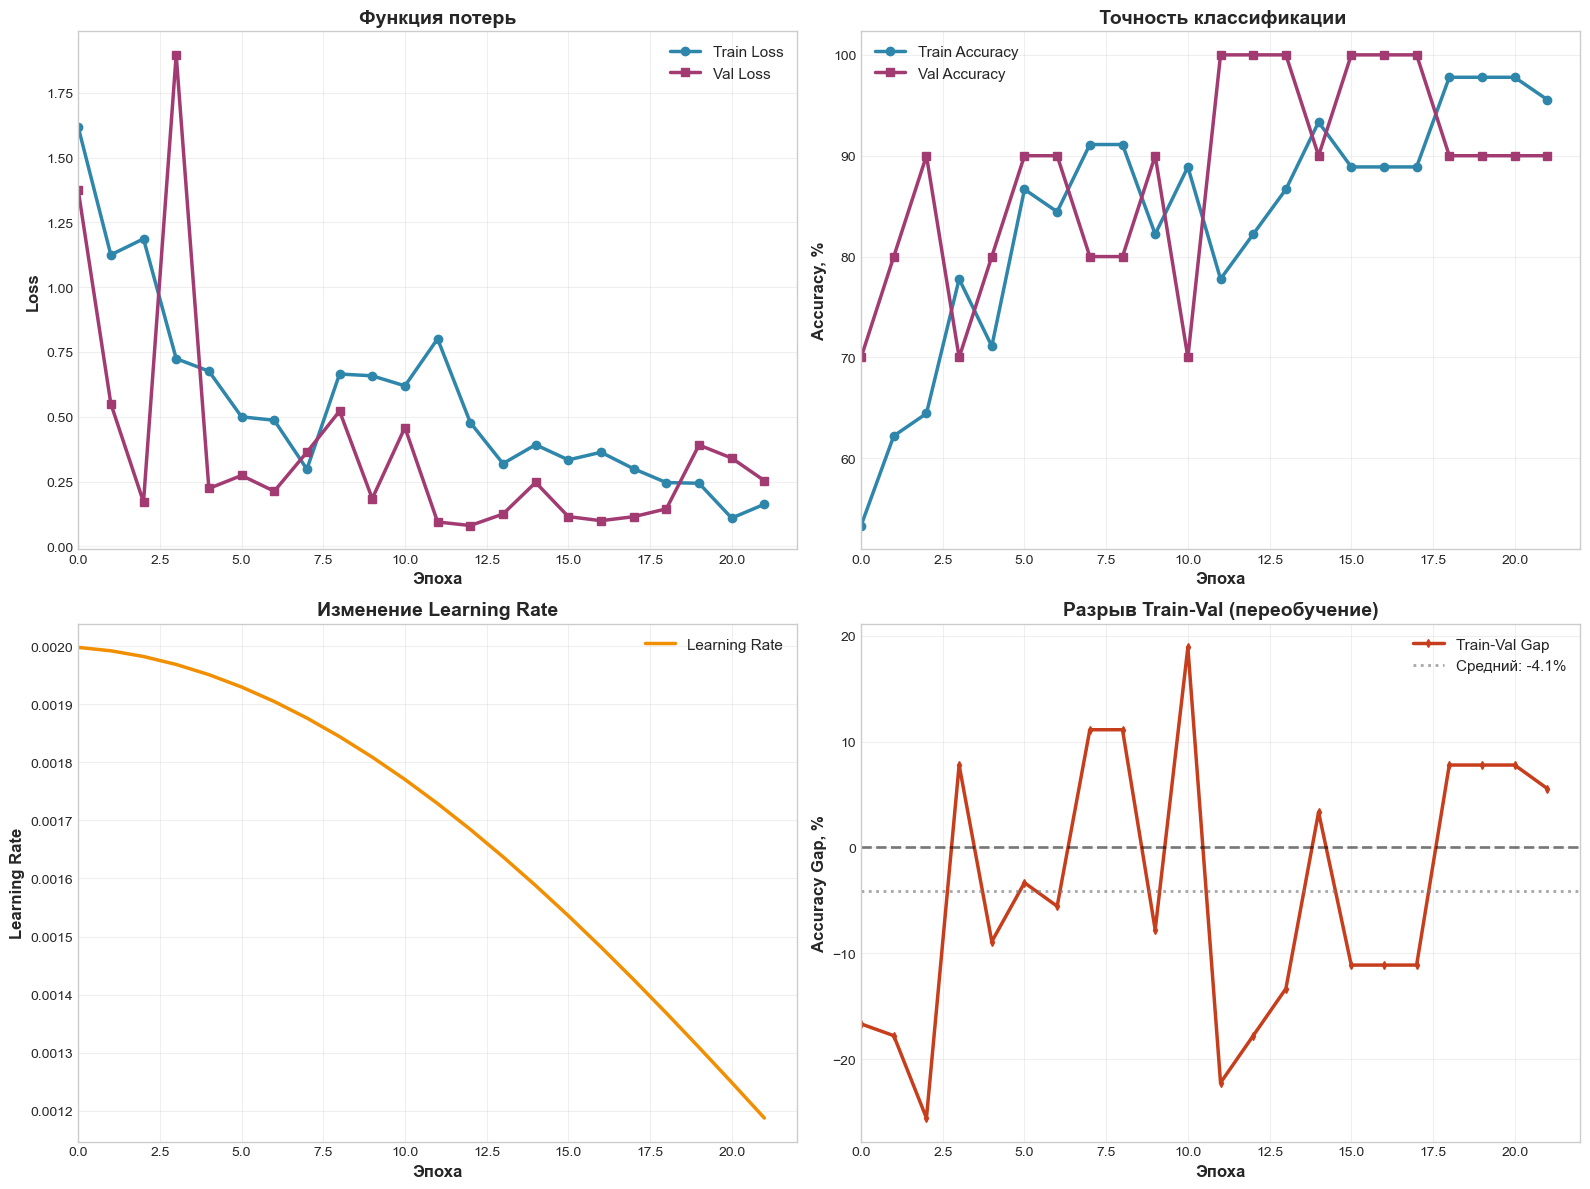

 ТЕСТИРОВАНИЕ МОДЕЛИ

 МЕТРИКИ НА TEST SET:
    Accuracy:  91.67%
    Precision: 0.9375
    Recall:    0.9167
    F1-Score:  0.9143

 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      galaxy     0.7500    1.0000    0.8571         3
      nebula     1.0000    0.6667    0.8000         3
      planet     1.0000    1.0000    1.0000         2
      quasar     1.0000    1.0000    1.0000         4

    accuracy                         0.9167        12
   macro avg     0.9375    0.9167    0.9143        12
weighted avg     0.9375    0.9167    0.9143        12



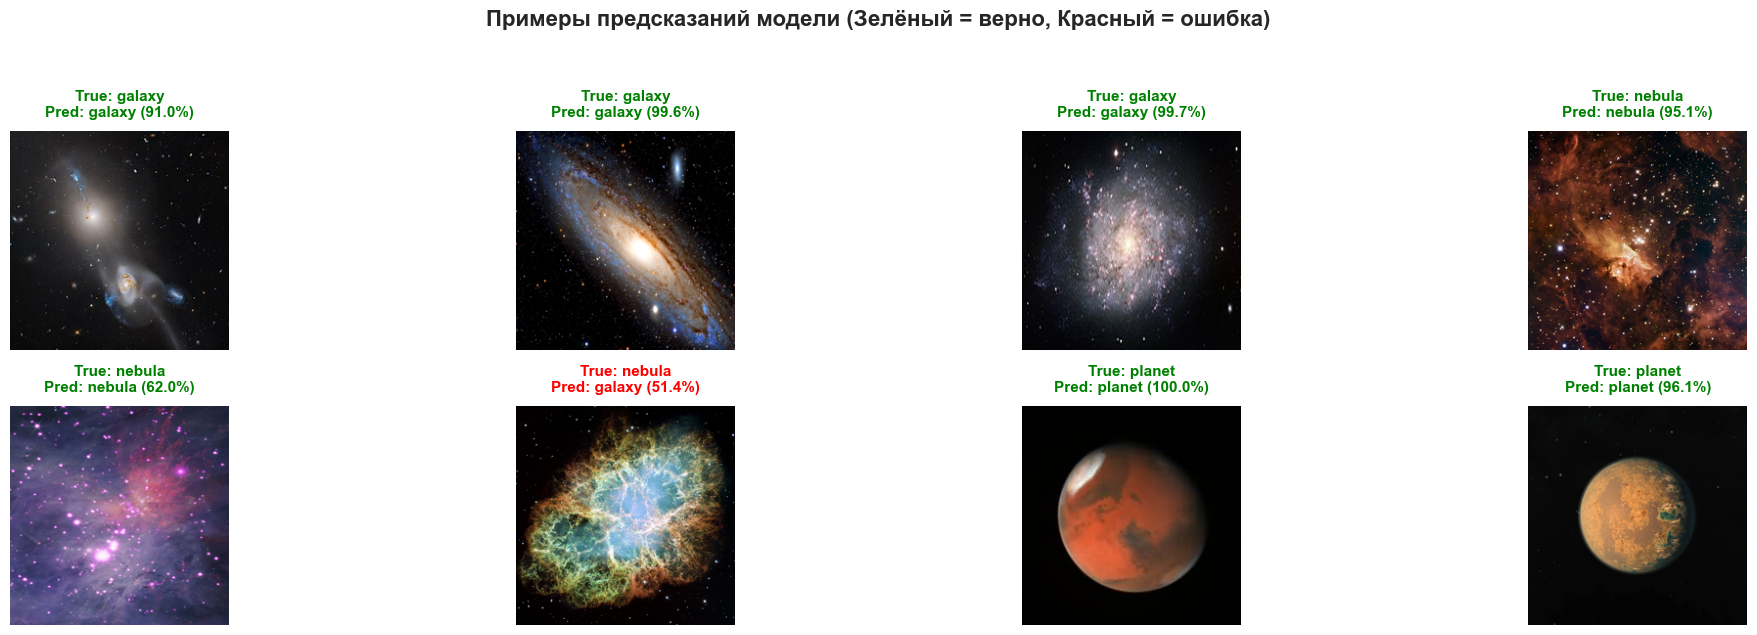

In [1]:
# ИМПОРТ БИБЛИОТЕК
import os
import sys
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR
from PIL import Image
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
# Настройка стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
# УСТРОЙСТВО (CPU/GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Устройство: {device}")
# КОНФИГУРАЦИя
class ExperimentConfig:
    # Пути 
    DATA_DIR = r'C:\Users\ASUS\Desktop\мо\датасет'
    MODEL_DIR = 'models'
    RESULTS_DIR = 'results'
    # Гиперпараметры 
    MODEL_NAME = 'resnet18'
    NUM_EPOCHS = 50
    BATCH_SIZE = 4
    LEARNING_RATE = 0.002
    WEIGHT_DECAY = 0.01
    # Разбиение данных
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    # Аугментация 
    USE_AUGMENTATION = True
    AUGMENTATION_LEVEL = 'high'
    # Ранняя остановка 
    EARLY_STOPPING = True
    PATIENCE = 10
    # Seed
    RANDOM_SEED = 42
config = ExperimentConfig()
os.makedirs(config.MODEL_DIR, exist_ok=True)
os.makedirs(config.RESULTS_DIR, exist_ok=True)
print(" СИСТЕМА КЛАССИФИКАЦИИ АСТРОНОМИЧЕСКИХ ОБЪЕКТОВ")
print(f" Дата: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Python: {sys.version.split()[0]}")
print(f" PyTorch: {torch.__version__}")
print(f" Устройство: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")
print(f"\nДанные: {os.path.abspath(config.DATA_DIR)}")
print(f" Модели: {os.path.abspath(config.MODEL_DIR)}")
print(f" Результаты: {os.path.abspath(config.RESULTS_DIR)}")
# ДАТАСЕТ
print(" ПОДГОТОВКА ДАННЫХ")
class SpaceDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_names = []
        
        for idx, cls in enumerate(sorted(os.listdir(root_dir))):
            cls_path = os.path.join(root_dir, cls)
            if os.path.isdir(cls_path) and not cls.endswith('.csv'):
                self.class_names.append(cls)
                for f in os.listdir(cls_path):
                    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                        self.images.append(os.path.join(cls_path, f))
                        self.labels.append(idx)
        
        print(f"\n Классов: {len(self.class_names)}")
        print(f" Изображений: {len(self.images)}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Ошибка {img_path}: {e}")
            image = Image.new('RGB', (224, 224), color='black')
        if self.transform:
            image = self.transform(image)
        return image, label, img_path

# ТРАНСФОРМЫ
def get_train_transforms(level='high'):
    if level == 'low':
        return transforms.Compose([
            transforms.Resize((256, 256)), transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(p=0.5), transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    elif level == 'medium':
        return transforms.Compose([
            transforms.Resize((256, 256)), transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(30), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15),
            transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    else:  # high
        return transforms.Compose([
            transforms.Resize((256, 256)), transforms.RandomCrop(224),
            transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5),
            transforms.RandomRotation(45), transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
            transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.8, 1.2)),
            transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
            transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
def get_val_transforms():
    return transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
# Загрузка
dataset_full = SpaceDataset(config.DATA_DIR, transform=None)
class_names = dataset_full.class_names
num_classes = len(class_names)
# РАЗБИЕНИЕ ДАННЫХ
print("\n Разбиение датасета...")
def stratified_split(dataset, train_ratio, val_ratio, test_ratio, seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    indices = np.arange(len(dataset))
    labels = np.array(dataset.labels)
    
    train_idx, temp_idx = [], []
    for cls in range(len(dataset.class_names)):
        cls_indices = indices[labels == cls]
        np.random.shuffle(cls_indices)
        n_train = int(len(cls_indices) * train_ratio)
        train_idx.extend(cls_indices[:n_train])
        temp_idx.extend(cls_indices[n_train:])
    
    val_idx, test_idx = [], []
    for cls in range(len(dataset.class_names)):
        cls_temp = [i for i in temp_idx if labels[i] == cls]
        np.random.shuffle(cls_temp)
        if len(cls_temp) > 1:
            n_val = max(1, int(len(cls_temp) * val_ratio / (val_ratio + test_ratio)))
            val_idx.extend(cls_temp[:n_val])
            test_idx.extend(cls_temp[n_val:])
        else:
            val_idx.extend(cls_temp)
    
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split(
    dataset_full, config.TRAIN_RATIO, config.VAL_RATIO, config.TEST_RATIO, config.RANDOM_SEED
)

print(f"   Train: {len(train_idx)} ({len(train_idx)/len(dataset_full)*100:.1f}%)")
print(f"   Val:   {len(val_idx)} ({len(val_idx)/len(dataset_full)*100:.1f}%)")
print(f"   Test:  {len(test_idx)} ({len(test_idx)/len(dataset_full)*100:.1f}%)")

train_dataset = torch.utils.data.Subset(dataset_full, train_idx)
val_dataset = torch.utils.data.Subset(dataset_full, val_idx)
test_dataset = torch.utils.data.Subset(dataset_full, test_idx)

train_dataset.dataset.transform = get_train_transforms(config.AUGMENTATION_LEVEL)
val_dataset.dataset.transform = get_val_transforms()
test_dataset.dataset.transform = get_val_transforms()

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)
# СОЗДАНИЕ МОДЕЛИ
print(" СОЗДАНИЕ МОДЕЛИ")
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features
model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(num_features, num_classes))

for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nАрхитектура: {config.MODEL_NAME}")
print(f"Всего параметров: {total_params:,}")
print(f" Обучаемых: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f" Классов: {num_classes} → {class_names}")
# ТРЕНЕР
class Trainer:
    def __init__(self, model, train_loader, val_loader, criterion, optimizer, 
                 scheduler, device, early_stopping=True, patience=10):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device
        self.early_stopping = early_stopping
        self.patience = patience
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'learning_rate': []}
        self.best_val_acc = 0.0
        self.best_model_state = None
        self.epochs_without_improvement = 0
    
    def train_epoch(self):
        self.model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels, _ in self.train_loader:
            images, labels = images.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        return running_loss / len(self.train_loader), 100.0 * correct / total
    
    def validate(self):
        self.model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels, _ in self.val_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        return running_loss / len(self.val_loader), 100.0 * correct / total
    
    def train(self, num_epochs):
        print(f"\n Обучение: {num_epochs} эпох | Batch: {config.BATCH_SIZE} | LR: {config.LEARNING_RATE}")
        start_time = time.time()
        for epoch in range(num_epochs):
            epoch_start = time.time()
            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc = self.validate()
            if isinstance(self.scheduler, ReduceLROnPlateau):
                self.scheduler.step(val_loss)
            else:
                self.scheduler.step()
            current_lr = self.optimizer.param_groups[0]['lr']
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            self.history['learning_rate'].append(current_lr)
            if val_acc > self.best_val_acc:
                self.best_val_acc = val_acc
                self.best_model_state = self.model.state_dict().copy()
                self.epochs_without_improvement = 0
            else:
                self.epochs_without_improvement += 1
            if self.early_stopping and self.epochs_without_improvement >= self.patience:
                print(f"\n Ранняя остановка на эпохе {epoch+1}")
                break
            epoch_time = time.time() - epoch_start
            print(f"Epoch {epoch+1:3d}/{num_epochs} | Train: {train_loss:.4f} ({train_acc:5.1f}%) | "
                  f"Val: {val_loss:.4f} ({val_acc:5.1f}%) | LR: {current_lr:.6f} | ⏱️ {epoch_time:.1f}s")
        total_time = time.time() - start_time
        print(f" Обучение завершено! ({total_time/60:.1f} мин)")
        print(f"Лучшая Val Accuracy: {self.best_val_acc:.2f}%")
        if self.best_model_state is not None:
            self.model.load_state_dict(self.best_model_state)
        return self.history
print(" ОБУЧЕНИЕ МОДЕЛИ")
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=config.NUM_EPOCHS)
trainer = Trainer(model, train_loader, val_loader, criterion, optimizer, scheduler, device, 
                  early_stopping=config.EARLY_STOPPING, patience=config.PATIENCE)
history = trainer.train(config.NUM_EPOCHS)
print(" ВИЗУАЛИЗАЦИЯ ОБУЧЕНИЯ")
def plot_training_history(history, results_dir):
    """Визуализация истории обучения - 4 графика"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    # 1. Loss
    axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2.5, markersize=6, color='#2E86AB')
    axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2.5, markersize=6, color='#A23B72')
    axes[0, 0].set_xlabel('Эпоха', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Функция потерь', fontsize=14, fontweight='bold')
    axes[0, 0].legend(fontsize=11, loc='best')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xlim(0, len(history['train_loss']))
    
    # 2. Accuracy
    axes[0, 1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2.5, markersize=6, color='#2E86AB')
    axes[0, 1].plot(history['val_acc'], label='Val Accuracy', marker='s', linewidth=2.5, markersize=6, color='#A23B72')
    axes[0, 1].set_xlabel('Эпоха', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Accuracy, %', fontsize=12, fontweight='bold')
    axes[0, 1].set_title(' Точность классификации', fontsize=14, fontweight='bold')
    axes[0, 1].legend(fontsize=11, loc='best')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim(0, len(history['train_acc']))
     # 3. Learning Rate
    axes[1, 0].plot(history['learning_rate'], label='Learning Rate', color='#F18F01', linewidth=2.5)
    axes[1, 0].set_xlabel('Эпоха', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Изменение Learning Rate', fontsize=14, fontweight='bold')
    axes[1, 0].legend(fontsize=11, loc='best')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xlim(0, len(history['learning_rate']))
    # 4. Gap (переобучение)
    gap = np.array(history['train_acc']) - np.array(history['val_acc'])
    axes[1, 1].plot(gap, label='Train-Val Gap', color='#C73E1D', linewidth=2.5, marker='d', markersize=4)
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=2)
    axes[1, 1].axhline(y=np.mean(gap), color='gray', linestyle=':', alpha=0.7, linewidth=2, label=f'Средний: {np.mean(gap):.1f}%')
    axes[1, 1].set_xlabel('Эпоха', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Accuracy Gap, %', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Разрыв Train-Val (переобучение)', fontsize=14, fontweight='bold')
    axes[1, 1].legend(fontsize=11, loc='best')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xlim(0, len(gap))
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, 'training_history.png'), dpi=300, bbox_inches='tight')
    plt.show()
plot_training_history(history, config.RESULTS_DIR)
# ТЕСТИРОВАНИЕ
print(" ТЕСТИРОВАНИЕ МОДЕЛИ")
model.eval()
all_preds, all_labels, all_probs, all_paths = [], [], [], []

with torch.no_grad():
    for images, labels, paths in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_paths.extend(paths)
# МЕТРИКИ И ОТЧЁТЫ
if len(all_labels) > 0:
    unique_labels = sorted(list(set(all_labels)))
    target_names = [class_names[i] for i in unique_labels]
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', labels=unique_labels)
    recall = recall_score(all_labels, all_preds, average='weighted', labels=unique_labels)
    f1 = f1_score(all_labels, all_preds, average='weighted', labels=unique_labels)
    print(f"\n МЕТРИКИ НА TEST SET:")
    print(f"    Accuracy:  {accuracy*100:.2f}%")
    print(f"    Precision: {precision:.4f}")
    print(f"    Recall:    {recall:.4f}")
    print(f"    F1-Score:  {f1:.4f}")
    print(f"\n CLASSIFICATION REPORT:")
    print("="*80)
    print(classification_report(all_labels, all_preds, labels=unique_labels, target_names=target_names, digits=4))
# ВИЗУАЛИЗАЦИЯ: ПРИМЕРЫ ПРЕДСКАЗАНИЙ
def predict_image(model, img_path, class_names, device):
    model.eval()
    transform = get_val_transforms()
    image = transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
        confidence = probs[pred_idx].item() * 100
    return class_names[pred_idx], confidence, probs.cpu().numpy()
# Показываем примеры из test set
n_examples = min(8, len(test_dataset))
if n_examples > 0:
    fig, axes = plt.subplots(2, 4, figsize=(22, 6))
    axes = axes.flatten()
    for i in range(n_examples):
        idx = test_dataset.indices[i]
        img_path = dataset_full.images[idx]
        true_label = dataset_full.labels[idx]
        pred_class, confidence, probs = predict_image(model, img_path, class_names, device)
        img = Image.open(img_path).resize((224, 224))
        axes[i].imshow(img)
        true_name = class_names[true_label]
        color = 'green' if pred_class == true_name else 'red'
        linewidth = 3 if pred_class == true_name else 3
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(linewidth)
        title = f"True: {true_name}\nPred: {pred_class} ({confidence:.1f}%)"
        axes[i].set_title(title, color=color, fontsize=11, fontweight='bold', pad=10)
        axes[i].axis('off')
    plt.suptitle('Примеры предсказаний модели (Зелёный = верно, Красный = ошибка)', 
                 fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'predictions_examples.png'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print(" Test set пуст, показываем случайные примеры из датасета:")
    n_examples = min(8, len(dataset_full))
    fig, axes = plt.subplots(2, 4, figsize=(22, 6))
    axes = axes.flatten()
    indices = np.random.choice(len(dataset_full), n_examples, replace=False)
    for i, idx in enumerate(indices):
        img_path = dataset_full.images[idx]
        true_label = dataset_full.labels[idx]
        pred_class, confidence, _ = predict_image(model, img_path, class_names, device)
        img = Image.open(img_path).resize((224, 224))
        axes[i].imshow(img)
        true_name = class_names[true_label]
        color = 'green' if pred_class == true_name else 'red'
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        title = f"True: {true_name}\nPred: {pred_class} ({confidence:.1f}%)"
        axes[i].set_title(title, color=color, fontsize=11, fontweight='bold', pad=10)
        axes[i].axis('off')
    plt.suptitle(' Примеры предсказаний', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(config.RESULTS_DIR, 'predictions_examples.png'), dpi=300, bbox_inches='tight')
    plt.show()
